# IT5092 Lab 04 — Hodgkin–Huxley vs Leaky Integrate-and-Fire

**Goal:** Implement and compare a reduced neuron model (LIF) with a biophysical conductance-based neuron model (Hodgkin–Huxley).

**You will produce:**
1. LIF baseline + **F–I curve**
2. HH baseline waveform + **gating variables**
3. HH **refractory pulse-gap-pulse** experiment
4. Short comparison paragraph (HH vs LIF)

In [2]:
pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 2.4 MB/s  0:00:02 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Import config + build time axis

import numpy as np
from config import DT, T_TOTAL
t = np.arange(0, T_TOTAL+DT, DT)
print("DT (ms):", DT, "| T_TOTAL (ms):", T_TOTAL, "| Samples:", len(t))

DT (ms): 0.01 | T_TOTAL (ms): 80.0 | Samples: 8001


## Part A — Input current and LIF baseline
We start with a simple step current `I(t)` and simulate a Leaky Integrate-and-Fire neuron.

- LIF integrates membrane potential using a **first-order ODE**
- When the voltage crosses threshold, it is **reset**
- A **refractory period** prevents immediate re-spiking (you will implement this in `lif.py`)

In [4]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.6 MB/s  0:00:00 eta 0:00:01
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


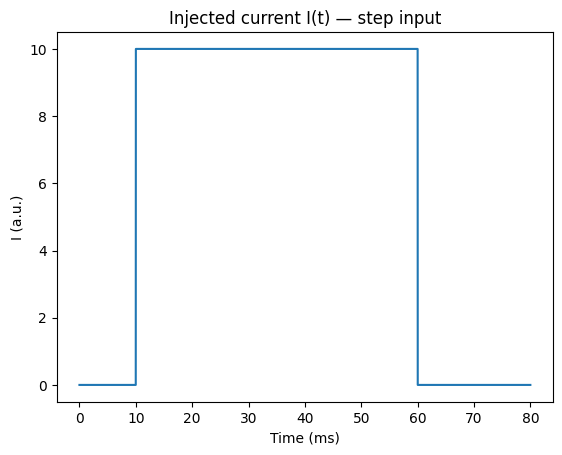

In [5]:
#Build the baseline injected current
import matplotlib.pyplot as plt

from models.input_current import step_current
I = step_current(t, t_on=10, t_off=60, amp=10)

plt.figure()
plt.plot(t, I)
plt.title("Injected current I(t) — step input")
plt.xlabel("Time (ms)")
plt.ylabel("I (a.u.)")
plt.show()

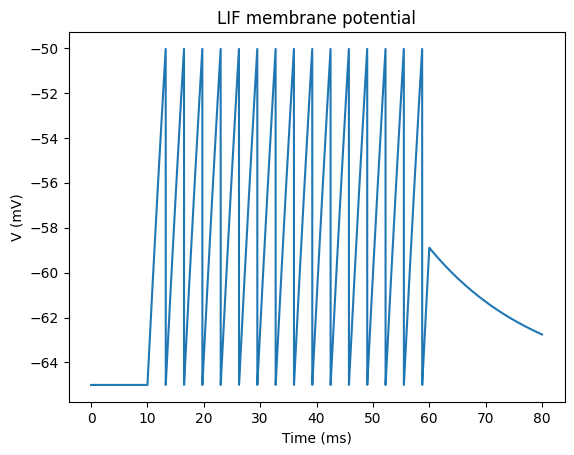

LIF spikes: 15 Rate(Hz): 187.5


In [6]:
#Run LIF baseline
# NOTE: This will fully work only after you complete TODO 1 in models/lif.py

from models.lif import simulate_lif
from utils.plotting import plot_trace
from utils.metrics import firing_rate

V_lif, sp_lif = simulate_lif(I, t)
plot_trace(t, V_lif, "LIF membrane potential", "V (mV)")
print("LIF spikes:", len(sp_lif), "Rate(Hz):", firing_rate(sp_lif, 0, T_TOTAL))

### TODO 5 — LIF F–I curve (in this notebook)

**Goal:** Show how firing rate increases as injected current increases.  
**What you do:**
1. Sweep current amplitude values
2. Run `simulate_lif(...)` for each amplitude
3. Compute firing rate in the *stimulus window* (10–60 ms)
4. Plot firing rate vs amplitude


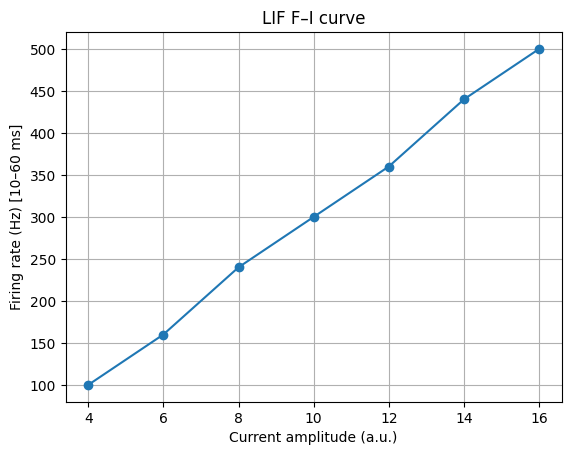

amps: [4, 6, 8, 10, 12, 14, 16]
rates: [100.0, 160.0, 240.0, 300.0, 360.0, 440.0, 500.0]


In [7]:
# Cell 5 — TODO 5: LIF F–I curve
# You may adjust amps range/step to get a clearer curve.
amps = [4, 6, 8, 10, 12, 14, 16]   # TODO: students can modify this list
rates = []

for amp in amps:
    I_amp = step_current(t, t_on=10.0, t_off=60.0, amp=amp)
    V_tmp, sp_tmp = simulate_lif(I_amp, t)
    rate_hz = firing_rate(sp_tmp, 10.0, 60.0)  # stim window only
    rates.append(rate_hz)

plt.figure()
plt.plot(amps, rates, marker="o")
plt.title("LIF F–I curve")
plt.xlabel("Current amplitude (a.u.)")
plt.ylabel("Firing rate (Hz) [10–60 ms]")
plt.grid(True)
plt.show()

print("amps:", amps)
print("rates:", rates)


## Part B — Hodgkin–Huxley (HH) baseline

HH is a **conductance-based** neuron model:
- Voltage changes due to ionic currents (Na⁺, K⁺, leak)
- Gating variables (m, h, n) control channel opening/closing
- More biologically realistic than LIF, but computationally heavier

> Your HH model will run only after you complete **TODO 2–4** in `models/hodgkin_huxley.py`.


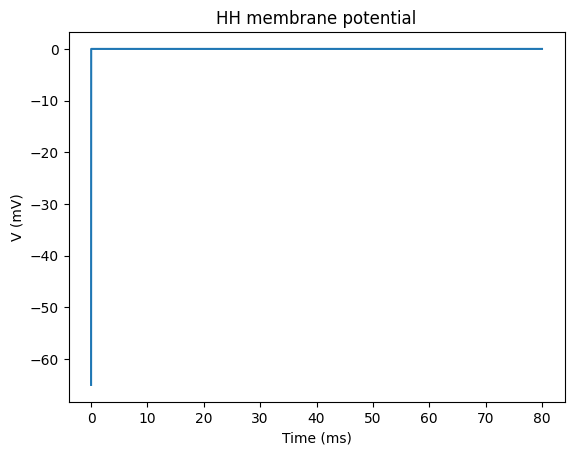

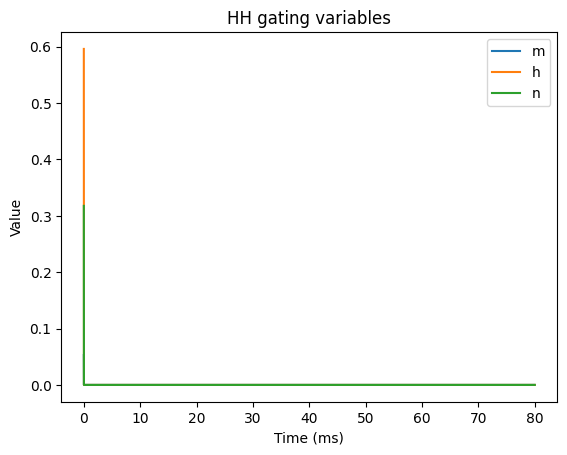

HH spikes: 1
HH rate (Hz) over full trial: 12.5


In [8]:
# Cell 6 — Run HH baseline (requires TODO 2–4 in models/hodgkin_huxley.py)
from models.hodgkin_huxley import simulate_hh
from utils.plotting import plot_hh_gates
from utils.metrics import spike_times_from_threshold

V_hh, m, h, n = simulate_hh(I, t)

plot_trace(t, V_hh, "HH membrane potential", "V (mV)")
plot_hh_gates(t, m, h, n)

sp_hh = spike_times_from_threshold(V_hh, t, thresh=0.0)  # 0 mV upward crossing
print("HH spikes:", len(sp_hh))
print("HH rate (Hz) over full trial:", firing_rate(sp_hh, 0.0, T_TOTAL))


### TODO 6 — HH refractory experiment (pulse–gap–pulse)

**Goal:** Estimate refractory behavior in HH using two brief pulses:
- Pulse 1 evokes a spike
- Pulse 2 may fail if it arrives too soon (refractory)
- Sweep the **gap** between pulses and detect if a second spike occurs

**Expected:** second-spike success increases when the gap becomes large enough.


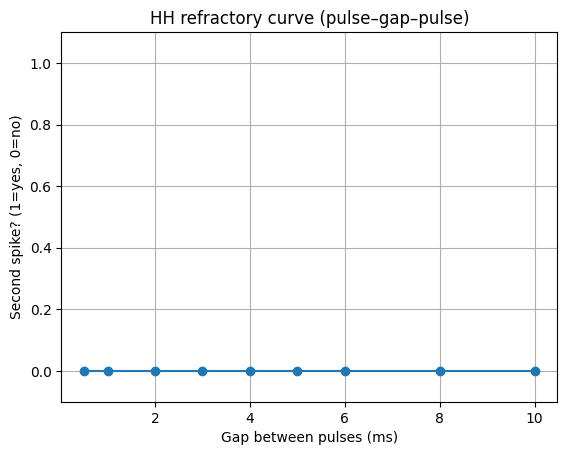

gaps: [0.5, 1, 2, 3, 4, 5, 6, 8, 10]
second spike present: [0, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
# Cell 7 — TODO 6: Pulse–gap–pulse refractory curve (HH)
from models.input_current import pulse_train

gaps = [0.5, 1, 2, 3, 4, 5, 6, 8, 10]  # ms (students can modify)
pulse_amp = 20.0                        # adjust if needed
pulse_w = 1.0                           # ms

second_spike_present = []

for g in gaps:
    pulses = [
        (10.0, 10.0 + pulse_w, pulse_amp),
        (10.0 + g, 10.0 + g + pulse_w, pulse_amp),
    ]
    I_ref = pulse_train(t, pulses)
    V_ref, m_ref, h_ref, n_ref = simulate_hh(I_ref, t)

    sp = spike_times_from_threshold(V_ref, t, thresh=0.0)
    second_spike_present.append(1 if len(sp) >= 2 else 0)

plt.figure()
plt.plot(gaps, second_spike_present, marker="o")
plt.title("HH refractory curve (pulse–gap–pulse)")
plt.xlabel("Gap between pulses (ms)")
plt.ylabel("Second spike? (1=yes, 0=no)")
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()

print("gaps:", gaps)
print("second spike present:", second_spike_present)


## Part C — HH vs LIF comparison (quantitative + qualitative)

We now compare both models under the same baseline step current.


LIF rate (Hz) [10–60 ms]: 300.0
HH  rate (Hz) [10–60 ms]: 20.0


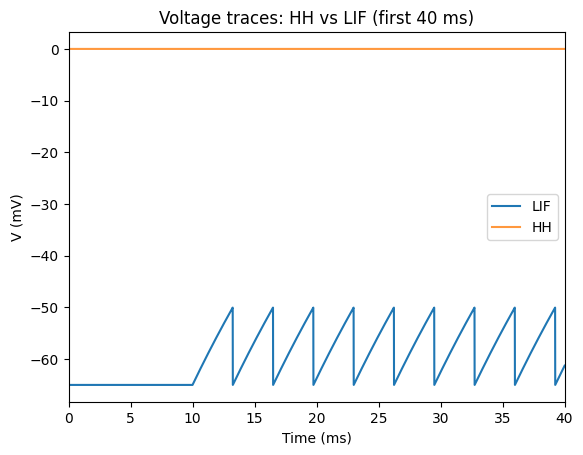

In [10]:
# Cell 8 — Compare HH vs LIF firing rates (stim window) and overlay traces
lif_rate = firing_rate(sp_lif, 10.0, 60.0)
hh_rate  = firing_rate(sp_hh, 10.0, 60.0)

print("LIF rate (Hz) [10–60 ms]:", lif_rate)
print("HH  rate (Hz) [10–60 ms]:", hh_rate)

plt.figure()
plt.plot(t, V_lif, label="LIF")
plt.plot(t, V_hh, label="HH", alpha=0.8)
plt.xlim(0, 40)
plt.title("Voltage traces: HH vs LIF (first 40 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.legend()
plt.show()


### TODO 7 — Short comparison (3–5 sentences)

Write a short scientific-style comparison:

- Which model is more **biophysically realistic**, and why?
- Which model is more **computationally efficient**, and why?
- Compare spike shape: HH waveform vs LIF “threshold-reset” spikes
- Compare how refractory effects appear in each model (HH intrinsic vs LIF implemented rule)

The Hodgkin–Huxley model is more biologically realistic because it explicitly models ionic currents through sodium and potassium channels using voltage-dependent gating variables. This allows it to reproduce realistic spike waveforms and intrinsic refractory dynamics. In contrast, the Leaky Integrate-and-Fire model simplifies neural behavior by using a threshold-reset mechanism, which makes it computationally efficient and suitable for large-scale neural simulations. The HH model produces smooth action potentials while the LIF model produces artificial spikes due to the reset rule. Therefore, HH is useful for studying biological mechanisms, while LIF is useful for large neural network simulations.